<span style = " color: blue; font-size : 20px; font-weight: bold;"> OVERVIEW - TỔNG QUAN DỰ ÁN <span>

<span style="color:green; font-size:18px; font-weight:bold;">Bối cảnh</span>

Đa dạng hóa danh mục đầu tư là một trong những nguyên tắc quan trọng trong quản lý tài chính nhằm giảm thiểu rủi ro mà vẫn duy trì khả năng sinh lợi. Tuy nhiên, mức độ hiệu quả của đa dạng hóa phụ thuộc đáng kể vào mối tương quan giữa các tài sản trong danh mục. Bên cạnh đó, việc lựa chọn tỷ trọng đầu tư hợp lý cũng đóng vai trò quan trọng trong việc tối ưu hóa mối quan hệ giữa lợi nhuận và rủi ro.

<span style="color:green; font-size:18px; font-weight:bold;">Mục tiêu dự án</span>

Mục tiêu chính của dự án là phân tích hiệu quả của đa dạng hóa danh mục đầu tư và ứng dụng mô hình Markowitz để xây dựng danh mục tối ưu trên thị trường chứng khoán Việt Nam. Các mục tiêu cụ thể bao gồm:

* Phân tích tương quan giữa các cổ phiếu:
  Xác định mức độ tương quan giữa các cổ phiếu thuộc nhiều nhóm ngành khác nhau và nhận diện các cặp cổ phiếu có tương quan cao nhất và thấp nhất.

* Đánh giá tác động của tương quan đến hiệu quả đa dạng hóa:
  So sánh hiệu quả đầu tư giữa danh mục gồm các cổ phiếu có tương quan cao và danh mục gồm các cổ phiếu có tương quan thấp thông qua các chỉ tiêu lợi nhuận, rủi ro và Sharpe Ratio.

* Phân tích ảnh hưởng của số lượng cổ phiếu đến rủi ro danh mục:
  Thực hiện mô phỏng các danh mục có quy mô từ 1 đến 18 cổ phiếu nhằm đánh giá lợi ích của đa dạng hóa trong việc giảm thiểu rủi ro.

* Tối ưu hóa danh mục đầu tư:
  Ứng dụng mô hình Markowitz (Mean-Variance Optimization) để xác định danh mục có Sharpe Ratio lớn nhất và danh mục có phương sai nhỏ nhất.

* Kiểm định hiệu quả đầu tư:
  Thực hiện backtest trên dữ liệu năm 2026 để đánh giá khả năng hoạt động của các chiến lược đầu tư trong điều kiện thị trường thực tế.

<span style="color:green; font-size:18px; font-weight:bold;">Các biến số chính</span>

<span style = "font-weight: bold">Biến đầu vào: <span>

* `Ticker`: Mã cổ phiếu.
* `Date`: Ngày giao dịch.
* `Close Price`: Giá đóng cửa của cổ phiếu.

<span style ="font-weight: bold">Biến được tính toán: <span>

* `Daily Return`: Suất sinh lợi ngày của cổ phiếu.
* `Correlation`: Hệ số tương quan giữa các cổ phiếu.
* `Covariance`: Hiệp phương sai giữa các suất sinh lợi.
* `Portfolio Return`: Lợi nhuận kỳ vọng của danh mục.
* `Portfolio Risk`: Rủi ro (độ biến động) của danh mục.
* `Sharpe Ratio`: Chỉ tiêu đánh giá lợi nhuận điều chỉnh theo rủi ro.
* `Portfolio Weights`: Tỷ trọng đầu tư của từng cổ phiếu trong danh mục.

<span style="color:green; font-size:18px; font-weight:bold;">Nguồn dữ liệu</span>

Dữ liệu được thu thập từ CafeF, bao gồm thông tin giá giao dịch lịch sử của các cổ phiếu niêm yết trên Sở Giao dịch Chứng khoán Thành phố Hồ Chí Minh (HOSE). Nghiên cứu sử dụng dữ liệu của 18 cổ phiếu thuộc 9 nhóm ngành khác nhau trong giai đoạn từ 01/01/2021 đến 01/06/2026. Dữ liệu này được sử dụng để phân tích mối tương quan giữa các cổ phiếu, đánh giá hiệu quả đa dạng hóa và xây dựng các danh mục đầu tư tối ưu.


<span style = " color: blue; font-size : 20px; font-weight: bold;">IMPORT LIBRARIES - NHẬP CÁC THƯ VIỆN CẦN THIẾT <span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

<span style = " color: blue; font-size : 20px; font-weight: bold;"> DATA PREPARATION - CHUẨN BỊ VÀ XỬ LÝ DỮ LIỆU <span>

In [ ]:
df=pd.read_csv("CafeF.HSX.Upto01.06.2026.csv")
df['<DTYYYYMMDD>'] = pd.to_datetime(df['<DTYYYYMMDD>'], format='%Y%m%d')
ticker = [
    "VCB","TCB",      
    "SSI","HCM",      
    "VHM","NLG",      
    "FPT","CMG",      
    "MWG","PNJ",     
    "HPG","HSG",      
    "REE","POW",      
    "VNM","MSN",      
    "GMD","VSC"       
]
df = df[df['<DTYYYYMMDD>']>='2021-01-01']
df = df[df['<DTYYYYMMDD>']<='2026-06-01']
stock_data=df[df['<Ticker>'].isin(ticker)].copy()
stock_data.set_index ('<DTYYYYMMDD>', inplace=True)
stock_data.sort_index(inplace=True) 
stock_data = stock_data.ffill().dropna()

Nghiên cứu sử dụng dữ liệu thứ cấp là giá đóng cửa điều chỉnh hằng ngày của 18 mã cổ phiếu đại diện cho 09 nhóm ngành kinh tế cốt lõi đang niêm yết trên Sở Giao dịch Chứng khoán Thành phố Hồ Chí Minh (HOSE). Toàn bộ dữ liệu gốc được thu thập từ nguồn uy tín CafeF trong giai đoạn 5 năm, từ ngày 01/01/2021 đến ngày 01/06/2026.

Việc lựa chọn danh mục mẫu tuân thủ nghiêm ngặt nguyên tắc: mỗi nhóm ngành chọn ra 02 doanh nghiệp đại diện. Thiết kế này nhằm đảm bảo tính đa dạng hóa tối đa về cấu trúc ngành kinh tế.Tạo cơ sở để bóc tách và phân tích các mức độ tương quan (correlation) khác nhau giữa các cặp cổ phiếu đồng ngành và liên ngành.Hoàn toàn tương thích với Lý thuyết Danh mục đầu tư hiện đại của Harry Markowitz (1952), phục vụ cho việc kiểm chứng hiệu quả giảm thiểu rủi ro phi hệ thống thông qua đa dạng hóa danh mục với các quy mô khác nhau.


| STT | Nhóm ngành (Sector) | Mã cổ phiếu | Tên doanh nghiệp / Ngân hàng |
| :---: | :--- | :---: | :--- |
| 1 | **Banking** (Ngân hàng) | VCB, TCB | Ngân hàng TMCP Ngoại thương Việt Nam, Ngân hàng TMCP Kỹ thương Việt Nam |
| 2 | **Securities / Financial Services** (Chứng khoán) | SSI, HCM | CTCP Chứng khoán SSI, CTCP Chứng khoán Thành phố Hồ Chí Minh |
| 3 | **Real Estate** (Bất động sản) | VHM, NLG | CTCP Vinhomes, CTCP Đầu tư Nam Long |
| 4 | **Technology** (Công nghệ) | FPT, CMG | CTCP FPT, Tập đoàn Công nghệ CMC |
| 5 | **Retail** (Bán lẻ) | MWG, PNJ | CTCP Đầu tư Thế giới Di động, CTCP Vàng bạc Đá quý Phú Nhuận |
| 6 | **Steel / Basic Materials** (Thép) | HPG, HSG | Tập đoàn Hòa Phát, Tập đoàn Hoa Sen |
| 7 | **Energy & Utilities** (Năng lượng & Tiện ích) | REE, POW | CTCP Cơ Điện Lạnh, Tổng Công ty Điện lực Dầu khí Việt Nam |
| 8 | **Food & Beverages** (Thực phẩm & Tiêu dùng) | VNM, MSN | CTCP Sữa Việt Nam (Vinamilk), Tập đoàn Masan |
| 9 | **Logistics** (Logistics) | GMD, VSC | CTCP Gemadept, CTCP Container Việt Nam (Viconship) |

Đối với các ngày giao dịch thiếu dữ liệu như ngày lễ hoặc thời gian tạm ngừng giao dịch,
nghiên cứu áp dụng phương pháp điền giá trị gần nhất (Forward Fill) nhằm duy trì tính liên tục
của chuỗi dữ liệu và hạn chế việc mất quan sát. Sau đó, các giá trị còn thiếu được loại bỏ để đảm
bảo chất lượng dữ liệu trước khi tiến hành phân tích.

<span style = " color: blue; font-size : 20px; font-weight: bold;"> STOCK RETURN AND CORRELATION ANALYSTS - LỢI SUẤT VÀ PHÂN TÍCH TƯƠNG QUAN<span>


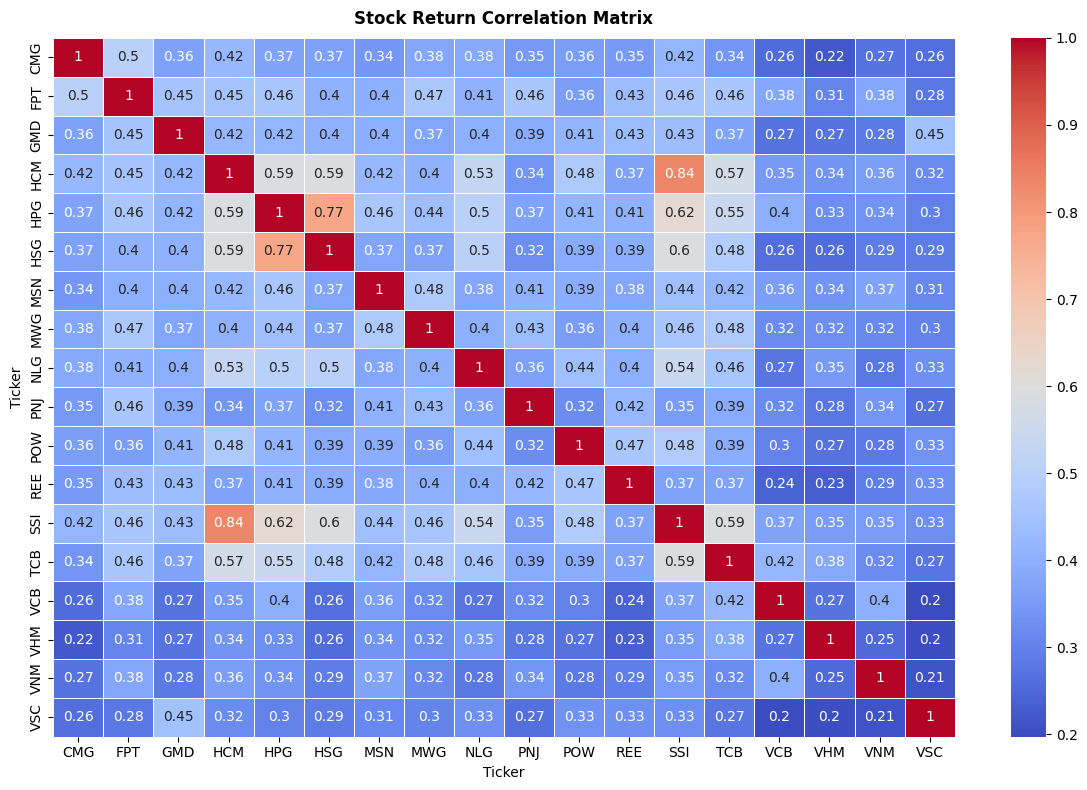

In [3]:
stock_data = stock_data.sort_values([ '<Ticker>',stock_data.index.name])
close_by_ticker = stock_data.groupby('<Ticker>')['<Close>']
stock_data['return'] = close_by_ticker.pct_change()
returns = stock_data.pivot_table(
    index=stock_data.index,
    columns="<Ticker>",
    values="return"
)
returns = returns.dropna()

corr_matrix = returns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm',linewidths=0.5)
plt.title("Stock Return Correlation Matrix", pad=10, fontweight = 'bold')
plt.xlabel("Ticker")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

Sau khi tính toán tỷ suất sinh lời hằng ngày (*daily return*) của 18 cổ phiếu qua hàm `.pct_change()` và loại bỏ các giá trị khuyết thiếu, nghiên cứu tiến hành xây dựng Ma trận hệ số tương quan Pearson nhằm đo lường mức độ liên kết tuyến tính giữa các mã cổ phiếu trong danh mục. 

**Biến động của các cặp cổ phiếu đồng ngành (Tương quan cao)**
Dữ liệu từ ma trận minh chứng rõ xu hướng biến động cùng chiều mạnh mẽ giữa các cổ phiếu trong cùng một nhóm ngành do chịu chung tác động vĩ mô:
* **Nhóm Chứng khoán (SSI - HCM):** Đạt mức tương quan cao nhất toàn danh mục với hệ số **0.84**, cho thấy tỷ suất sinh lời của hai mã này gần như đồng nhất.
* **Nhóm Thép (HPG - HSG):** Ghi nhận hệ số tương quan chặt chẽ ở mức **0.77** do phụ thuộc chung vào chu kỳ giá nguyên vật liệu và thị trường bất động sản đầu ra.
* **Nhóm Ngân hàng (VCB - TCB):** Mức tương quan dừng lại ở mức trung bình **0.42** do có sự phân hóa về cấu trúc dòng vốn giữa khối quốc doanh và khối tư nhân.

**Biến động của các cặp cổ phiếu khác ngành (Tương quan thấp)**
Trái ngược với nhóm đồng ngành, mối quan hệ chéo giữa các cổ phiếu khác ngành mở ra cơ hội giảm thiểu rủi ro nhờ hệ số tương quan thấp (vùng màu xanh lam chiếm chủ đạo):
* **Cổ phiếu Logistics (VSC):** Duy trì mức tương quan cực thấp với các ngành khác, cụ thể chỉ đạt **0.20** với Ngân hàng (`VCB`) và **0.20** với Bất động sản (`VHM`).
* **Phần lớn các cặp chéo ngành khác:** Hệ số tương quan phổ biến chỉ dao động trong biên độ từ **0.25 đến 0.45**.

> **Ý nghĩa thực tiễn:** Hệ số tương quan giữa các cổ phiếu khác ngành ở mức thấp đến trung bình là điều kiện lý tưởng theo lý thuyết Markowitz. Đây là cơ sở định lượng để tiến hành phân bổ tỷ trọng, giúp thiết lập danh mục tối ưu hóa nhằm triệt tiêu rủi ro phi hệ thống trong các bước tiếp theo.

> **Kết luận căn cứ lý thuyết Markowitz:** Hệ số tương quan giữa phần lớn các cặp cổ phiếu khác ngành trong ma trận đều nằm trong khoảng từ **0.20 đến 0.45**. Việc các cổ phiếu có mức tương quan từ thấp đến trung bình là một điều kiện lý tưởng để thiết lập các danh mục đầu tư đa dạng hóa nhằm triệt tiêu phần lớn rủi ro phi hệ thống (*unsystematic risk*), đồng thời tối ưu hóa đường biên hiệu quả (*efficient frontier*) trong các bước phân tích tiếp theo.

<span style = " color: blue; font-size : 20px; font-weight: bold;">PORTFOLIO PERFORMANCE COMPARISON BY CORRELATION LEVEL - SO SÁNH HIỆU QUẢ DANH MỤC THEO MỨC ĐỘ TƯƠNG QUAN<span>



Top 10 Highest Correlated Stock Pairs:
        Pair  Correlation
66   HCM-SSI     0.836808
77   HPG-HSG     0.772698
84   HPG-SSI     0.622637
102  HSG-SSI     0.595176
59   HCM-HSG     0.590747
229  SSI-TCB     0.590349
58   HCM-HPG     0.586544
67   HCM-TCB     0.565482
85   HPG-TCB     0.545181
156  NLG-SSI     0.543107

Top 10 Lowest Correlated Stock Pairs:
        Pair  Correlation
269  VCB-VSC     0.197284
287  VHM-VSC     0.201170
305  VNM-VSC     0.212542
15   CMG-VHM     0.220624
213  REE-VHM     0.228847
212  REE-VCB     0.240810
286  VHM-VNM     0.251665
14   CMG-VCB     0.255976
105  HSG-VHM     0.258698
17   CMG-VSC     0.260694

           Metric  High Correlation Portfolio  Low Correlation Portfolio
Annualized Return                    0.182369                   0.196385
  Annualized Risk                    0.358250                   0.235750
     Sharpe Ratio                    0.425316                   0.705771


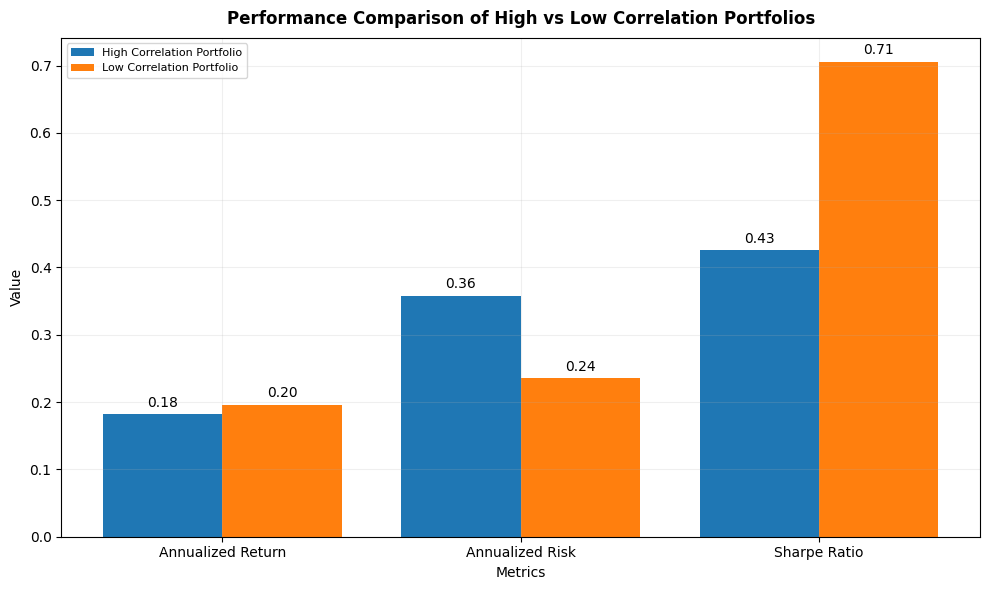

In [4]:
corr_matrix.index.name = "Ticker_1"
corr_matrix.columns.name = "Ticker_2"
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Ticker_1", "Ticker_2", "Correlation"]

corr_pairs = corr_pairs[corr_pairs["Ticker_1"] != corr_pairs["Ticker_2"]]

corr_pairs["Pair"] = corr_pairs.apply(
    lambda row: "-".join(sorted([row["Ticker_1"], row["Ticker_2"]])),
    axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset="Pair")

highest_corr = corr_pairs.sort_values(
    by="Correlation",
    ascending=False
).head(10)
print("\nTop 10 Highest Correlated Stock Pairs:")
print(highest_corr[["Pair", "Correlation"]])

lowest_corr = corr_pairs.sort_values(
    by="Correlation",
    ascending=True
).head(10)
print("\nTop 10 Lowest Correlated Stock Pairs:")
print(lowest_corr[["Pair", "Correlation"]])

high_corr_portfolio = ["HCM", "SSI", "HPG", "HSG"]
low_corr_portfolio = ["VCB", "FPT", "MWG", "GMD"]

risk_free_rate = 0.03  

high_corr_portfolio_daily_return = returns[high_corr_portfolio].mean(axis=1)
low_corr_portfolio_daily_return = returns[low_corr_portfolio].mean(axis=1)

high_corr_portfolio_return = high_corr_portfolio_daily_return.mean() * 252
low_corr_portfolio_return = low_corr_portfolio_daily_return.mean() * 252

high_portfolio_risk = high_corr_portfolio_daily_return.std()*252**0.5
low_portfolio_risk = low_corr_portfolio_daily_return.std()*252**0.5


high_portfolio_sharpe = (high_corr_portfolio_return - risk_free_rate) / high_portfolio_risk
low_portfolio_sharpe = (low_corr_portfolio_return - risk_free_rate) / low_portfolio_risk

metrics = ["Annualized Return", "Annualized Risk", "Sharpe Ratio"]
high_value = [high_corr_portfolio_return, high_portfolio_risk, high_portfolio_sharpe]
low_value = [low_corr_portfolio_return, low_portfolio_risk, low_portfolio_sharpe]
comparison_df = pd.DataFrame({
    "Metric": metrics,
    "High Correlation Portfolio": high_value,
    "Low Correlation Portfolio": low_value})
comparison_df = comparison_df.to_string(index=False)
print("\n" + comparison_df)

x = np.arange(len(metrics))
plt.figure(figsize=(10, 6))
bar_1 = plt.bar(x -0.2, high_value, width=0.4, label="High Correlation Portfolio")
bar_2 = plt.bar(x +0.2, low_value, width=0.4, label="Low Correlation Portfolio")
plt.bar_label(bar_1, padding=3, fmt="%.2f", size = 10)
plt.bar_label(bar_2, padding=3, fmt="%.2f", size = 10)
plt.title("Performance Comparison of High vs Low Correlation Portfolios", pad=10, fontweight = 'bold')
plt.xticks(x, metrics)
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.legend(fontsize=8)
plt.grid(alpha = 0.2)
plt.tight_layout()
plt.show()

Để kiểm chứng giá trị thực tiễn của Ma trận hệ số tương quan trong việc quản trị rủi ro, nghiên cứu tiến hành phân tách các cặp cổ phiếu biến động mạnh/yếu nhất và giả định xây dựng hai danh mục đầu tư (bằng phương pháp trọng số đều - *Equal Weight*) nhằm so sánh hiệu quả hiệu năng (Performance Comparison):
* **Danh mục Tương quan cao (High Correlation Portfolio):** Gồm 4 mã `HCM`, `SSI`, `HPG`, `HSG` (đại diện cho các cặp cổ phiếu cùng ngành hoặc có mối liên hệ ngành với nhau).
* **Danh mục Tương quan thấp (Low Correlation Portfolio):** Gồm 4 mã `VCB`, `FPT`, `MWG`, `GMD` (đại diện cho nhóm cổ phiếu không có nhiều mối liên hệ ngành với nhau).

Tỷ suất sinh lời phi rủi ro (*Risk-free rate*) được giả định ở mức 3% ($0.03$/năm). Dữ liệu lợi nhuận và rủi ro được chuẩn hóa theo năm (Annualized với chu kỳ 252 ngày giao dịch).


| Chỉ tiêu tài chính (Metric) | Danh mục Tương quan cao | Danh mục Tương quan thấp | Chênh lệch |
| :--- | :---: | :---: | :---: |
| **Tỷ suất sinh lời chuẩn hóa năm** (*Annualized Return*) | 18.24% | 19.64% | +1.40% |
| **Rủi ro chuẩn hóa năm (Độ lệch chuẩn)** (*Annualized Risk*) | 35.83% | 23.58% | -12.25% |
| **Chỉ số Sharpe** (*Sharpe Ratio*) | 0.43 | 0.71 | +0.28 |

* **Về khía cạnh rủi ro (Biến động):** Đây là điểm cốt lõi chứng minh hiệu ứng đa dạng hóa. Danh mục Tương quan cao có mức rủi ro lên tới **35.83%**, trong khi Danh mục Tương quan thấp chỉ ghi nhận mức rủi ro **23.58%**. Việc phân bổ dòng tiền vào các tài sản có tương quan thấp đã giúp **triệt tiêu tới 12.25% mức độ biến động** (giảm gần 1/3 tổng rủi ro). Do các tài sản không đồng thời giảm điểm cùng một lúc, các mức lỗ của cổ phiếu này được bù đắp bởi sự ổn định của cổ phiếu khác.
* **Về khía cạnh tỷ suất sinh lời:** Danh mục Tương quan thấp không những an toàn hơn mà còn đem lại mức sinh lời tối ưu hơn (**19.64%** so với **18.24%**). Điều này cho thấy việc tập trung quá mức vào các ngành có tính chu kỳ cao (như Thép, Chứng khoán) đôi khi không mang lại mức sinh lời vượt trội tương xứng với rủi ro phải gánh chịu trong dài hạn.
* **Hiệu quả phần thưởng trên rủi ro (Chỉ số Sharpe):** Chỉ số Sharpe của Danh mục Tương quan thấp đạt **0.71**, vượt trội đáng kể so với mức **0.43** của Danh mục Tương quan cao. Trên một đơn vị rủi ro chấp nhận, danh mục đa dạng hóa tốt mang lại hiệu quả sinh lời cao gấp 1.65 lần so với danh mục tập trung.

> **Kết luận căn cứ lý thuyết Markowitz:** Kết quả này phù hợp với lý thuyết danh mục đầu tư hiện đại của Markowitz, theo đó việc kết hợp các tài sản có tương quan thấp giúp giảm rủi ro danh mục thông qua hiệu ứng đa dạng hóa. Ta có thể thấy, đối với nhóm cổ phiểu có tương quan thấp, mức độ rủi ro đã giảm hơn 34% so với nhóm cổ phiếu có tương quan cao. Đồng thời, hiệu suát sinh lợi trên một đơn vị rủi ro cũng tăng gần 65% so với nhóm cổ phiếu có tương quan cao.

<span style = " color: BLUE; font-size : 20px; font-weight: bold;">IMPACT OF PORTFOLIO DIVERSIFICATION ON RISK - ẢNH HƯỞNG ĐA DẠNG HÓA DANH MỤC ĐẾN RỦI RO <span>

    Number of Stocks  Average Risk  Min Risk  Max Risk
0                  1      0.356330  0.240260  0.448095
1                  2      0.301262  0.207447  0.415485
2                  3      0.276085  0.199926  0.375249
3                  4      0.264927  0.200970  0.339963
4                  5      0.257914  0.203674  0.335365
5                  6      0.251559  0.198885  0.304424
6                  7      0.248507  0.205459  0.302812
7                  8      0.245427  0.206203  0.297035
8                  9      0.242359  0.205070  0.283854
9                 10      0.240881  0.209326  0.276964
10                11      0.239863  0.212029  0.274315
11                12      0.238430  0.211704  0.267450
12                13      0.236935  0.212175  0.261121
13                14      0.236277  0.216542  0.257105
14                15      0.235452  0.217610  0.252341
15                16      0.234893  0.222507  0.247553
16                17      0.234244  0.227733  0.240371
17        

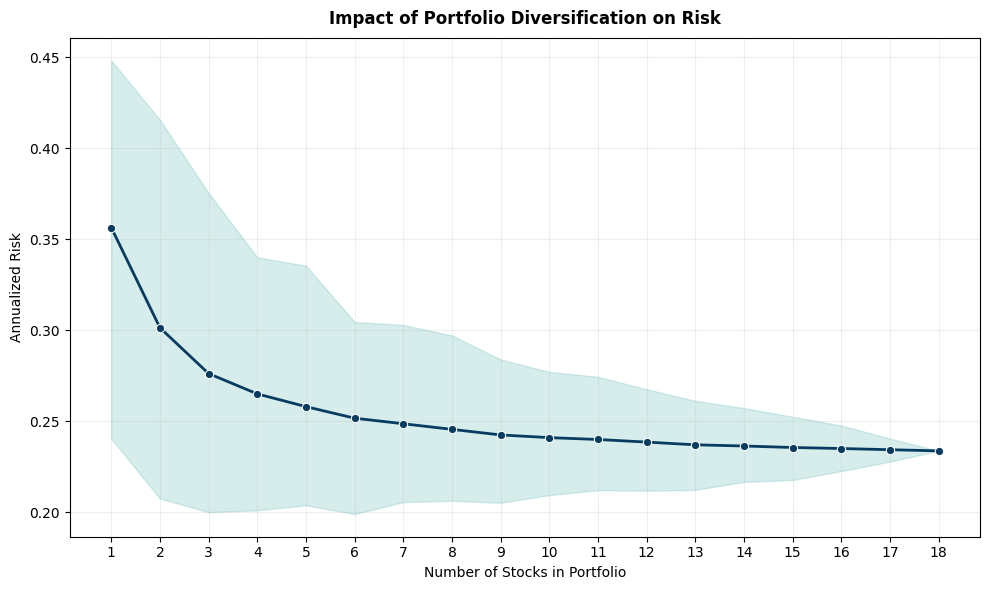

In [5]:
stocks = stock_data["<Ticker>"].unique()
num_simulations = 1000
portfolio_risk_results = []
np.random.seed(2026)

for num_stock in range (1, (len(stocks)+1)):
    risk = []
    for i in range(0, num_simulations):
        selected_stocks = np.random.choice(stocks, size=num_stock, replace=False)
        portfolio_daily_return = returns[selected_stocks].mean(axis=1)
        portfolio_annual_risk = portfolio_daily_return.std()*(252**0.5)
        risk.append(portfolio_annual_risk)
    avg_risk = np.mean(risk)
    min_risk = np.min(risk)
    max_risk = np.max(risk)
    portfolio_risk_results.append({
        "Number of Stocks": num_stock,
        "Average Risk": avg_risk,
        "Min Risk": min_risk,
        "Max Risk": max_risk
    })
risk_by_num_stocks_df = pd.DataFrame(portfolio_risk_results)
print(risk_by_num_stocks_df)

plt.figure(figsize=(10, 6))
sns.lineplot(data = risk_by_num_stocks_df, x = 'Number of Stocks', y = 'Average Risk', linewidth = 2, marker ='o',color = "#083b60")
plt.fill_between(risk_by_num_stocks_df ['Number of Stocks'], 
                 risk_by_num_stocks_df['Min Risk'], 
                 risk_by_num_stocks_df['Max Risk'], color="#39a8a2", alpha=0.2)
plt.xticks(risk_by_num_stocks_df['Number of Stocks'])
plt.xlabel("Number of Stocks in Portfolio")
plt.ylabel("Annualized Risk")
plt.title("Impact of Portfolio Diversification on Risk", pad=10, fontweight = 'bold')
plt.grid(alpha = 0.2)
plt.tight_layout()
plt.show()

Để kiểm chứng quy luật giảm thiểu rủi ro phi hệ thống khi mở rộng quy mô danh mục, nghiên cứu thực hiện thuật toán mô phỏng Monte Carlo với $1,000$ lần lặp cho mỗi cấu trúc danh mục (từ 1 đến 18 cổ phiếu). Tại mỗi lượt, hệ thống lựa chọn ngẫu nhiên không lặp (*random choice without replacement*) một số lượng cổ phiếu nhất định từ rổ 18 tài tài sản, tính toán độ lệch chuẩn lợi nhuận chuẩn hóa năm để đo lường các giá trị rủi ro trung bình (*Average Risk*), rủi ro thấp nhất (*Min Risk*), và rủi ro cao nhất (*Max Risk*).

| Số lượng cổ phiếu (N) | Rủi ro trung bình (Average Risk) | Rủi ro thấp nhất (Min Risk) | Rủi ro cao nhất (Max Risk) | Biên độ biến động (Max - Min) |
| :---: | :---: | :---: | :---: | :---: |
| **1** | 35.63% | 24.03% | 44.81% | 20.78% |
| **2** | 30.13% | 20.74% | 41.55% | 20.81% |
| **3** | 27.61% | 19.99% | 37.52% | 17.53% |
| **5** | 25.79% | 20.37% | 33.54% | 13.17% |
| **10** | 24.09% | 20.93% | 27.70% | 6.77% |
| **15** | 23.55% | 21.76% | 25.23% | 3.47% |
| **18** | 23.36% | 23.36% | 23.36% | 0.00% |


Kết quả mô phỏng Monte Carlo cho thấy rủi ro danh mục giảm đáng kể khi số lượng cổ phiếu tăng từ mức thấp lên mức trung bình. Cụ thể, độ lệch chuẩn năm hóa trung bình (*Average Risk*) giảm từ **35.63%** ở danh mục gồm 1 cổ phiếu xuống còn **24.09%** ở danh mục gồm 10 cổ phiếu, tương đương mức giảm **11.54 điểm phần trăm** (giảm khoảng **32.4%** so với mức ban đầu). Đồng thời, biên độ biến động giữa danh mục rủi ro nhất và an toàn nhất cũng thu hẹp mạnh mẽ từ **20.78%** xuống chỉ còn **6.77%**. Điều này cho thấy hiệu quả đa dạng hóa phát huy mạnh mẽ nhất trong giai đoạn đầu, khi các rủi ro phi hệ thống đặc trưng của từng doanh nghiệp được phân tán hiệu quả trên nhiều tài sản hơn.

Tuy nhiên, khi số lượng cổ phiếu tiếp tục tăng vượt ngưỡng khoảng 10 mã, tốc độ giảm rủi ro bắt đầu chậm lại rõ rệt. Từ danh mục gồm 10 cổ phiếu đến khi tích hợp toàn bộ 18 cổ phiếu, độ lệch chuẩn trung bình chỉ giảm thêm vỏn vẹn **0.73 điểm phần trăm** (từ **24.09%** xuống **23.36%**), đồng thời khoảng cách giữa biên độ rủi ro lớn nhất và nhỏ nhất hội tụ hoàn toàn về 0. Hiện tượng này cho thấy lợi ích biên của đa dạng hóa có xu hướng suy giảm khi quy mô danh mục ngày càng lớn, do phần lớn rủi ro phi hệ thống đã bị triệt tiêu triệt để, và phần rủi ro cốt lõi còn lại (**23.36%**) chủ yếu gắn liền với biến động chung mang tính hệ thống của toàn thị trường mẫu. 


> **Kết luận tổng quan:** Nhìn chung, kết quả thực nghiệm từ mô hình Monte Carlo tái khẳng định quy luật của lý thuyết Markowitz: việc gia tăng số lượng cổ phiếu giúp hạ thấp rủi ro biên và ổn định danh mục. Tuy nhiên, lợi ích này giảm dần theo quy mô và tiệm cận về một mức rủi ro hệ thống không thể phân tán, minh chứng rằng số lượng tài sản không phải là yếu tố duy nhất quyết định, mà chất lượng tương quan giữa các nhóm ngành mới là chìa khóa để tối ưu hóa hiệu quả cấu trúc danh mục đầu tư.

<span style = " color: BLUE; font-size : 20px; font-weight: bold;">EFFICIETNT FRONTIER AND OPTIMAL PORTFOLHTS - ĐƯỜNG BIÊN HIỆU QUẢ VÀ TRỌNG SỐ TỐI ƯU


=== Expected Annualized Returns ===
Ticker
CMG    0.2065
FPT    0.3108
GMD    0.2499
HCM    0.2360
HPG    0.1447
HSG    0.0975
MSN    0.0867
MWG    0.1791
NLG    0.1608
PNJ    0.1660
POW    0.0953
REE    0.2143
SSI    0.2574
TCB    0.2209
VCB    0.1007
VHM    0.1923
VNM   -0.0258
VSC    0.1813
dtype: float64


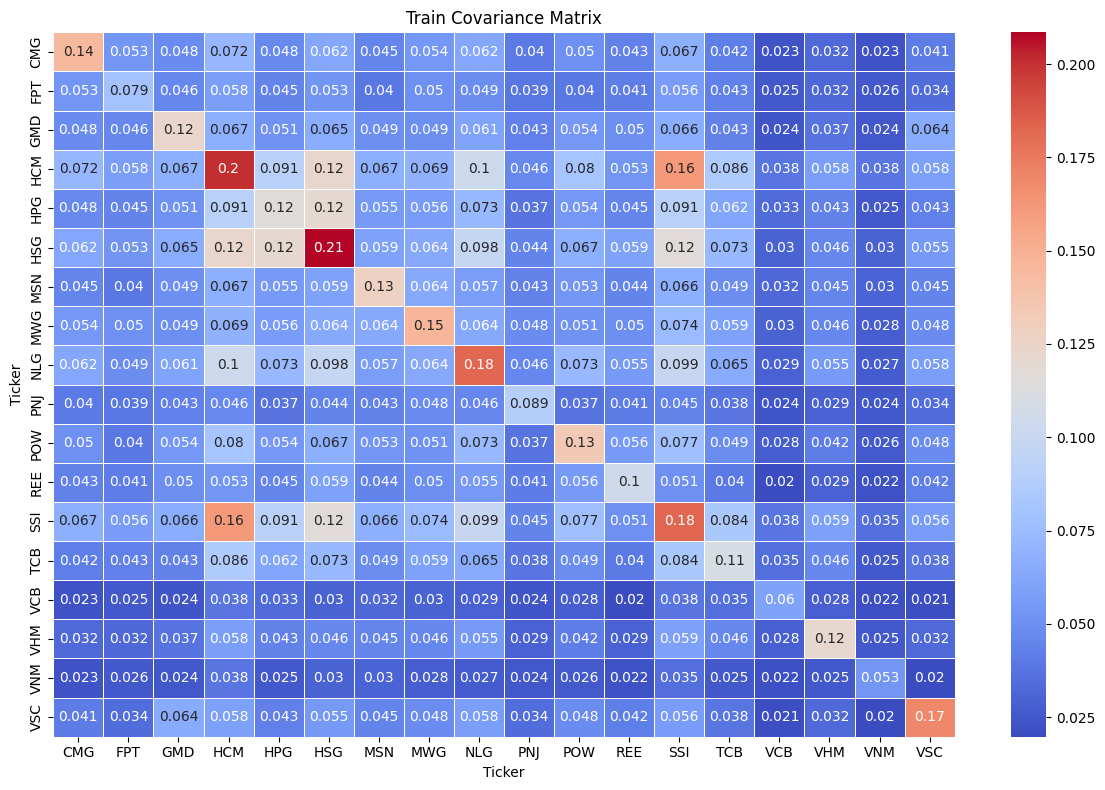

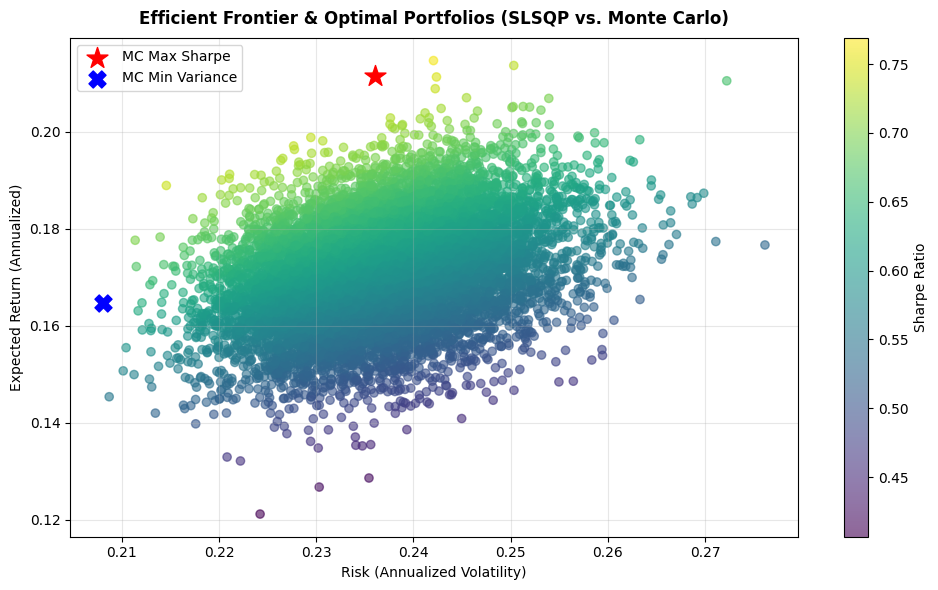


=== Optimization using SLSQP (Exact Weights) ===

Max Sharpe Portfolio Weights:
   Ticker  Weight
1     FPT  0.7183
2     GMD  0.1041
15    VHM  0.0720
11    REE  0.0566
13    TCB  0.0491
17    VSC  0.0000
0     CMG  0.0000
14    VCB  0.0000
7     MWG  0.0000
12    SSI  0.0000
9     PNJ  0.0000
6     MSN  0.0000
4     HPG  0.0000
5     HSG  0.0000
8     NLG  0.0000
3     HCM  0.0000
10    POW  0.0000
16    VNM  0.0000

Minimum Variance Portfolio Weights:
   Ticker  Weight
16    VNM  0.3404
14    VCB  0.2848
9     PNJ  0.0817
11    REE  0.0795
1     FPT  0.0708
15    VHM  0.0572
17    VSC  0.0503
0     CMG  0.0311
2     GMD  0.0041
4     HPG  0.0000
3     HCM  0.0000
5     HSG  0.0000
10    POW  0.0000
6     MSN  0.0000
8     NLG  0.0000
7     MWG  0.0000
13    TCB  0.0000
12    SSI  0.0000


In [18]:
train_returns = returns[returns.index < "2026-01-01"]
test_returns = returns[returns.index >= "2026-01-01"]

expected_returns_bt = train_returns.mean() * 252
covariance_matrix_bt = train_returns.cov() * 252
expected_returns_bt.index.name = "Ticker"
stocks = expected_returns_bt.index
n_assets = len(stocks)

print("\n=== Expected Annualized Returns ===")
print(expected_returns_bt)

plt.figure(figsize=(12,8))
sns.heatmap(covariance_matrix_bt, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Train Covariance Matrix")
plt.xlabel ("Ticker")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

risk_free_rate = 0.03
np.random.seed(2026)

num_portfolios = 10000
portfolio_results = []

for i in range(num_portfolios):
    weight = np.random.random(n_assets)
    weight = weight / np.sum(weight)
    p_return = np.dot(weight, expected_returns_bt)
    p_risk = np.sqrt(np.dot(weight.T, np.dot(covariance_matrix_bt, weight)))
    s_ratio = (p_return - risk_free_rate) / p_risk if p_risk != 0 else 0
    portfolio_results.append({
        "Return": p_return,
        "Risk": p_risk,
        "Sharpe Ratio": s_ratio,
        "Weights": weight
    })

markowitz_results = pd.DataFrame(portfolio_results)
mc_max_sharpe = markowitz_results.loc[markowitz_results['Sharpe Ratio'].idxmax()]
mc_min_variance = markowitz_results.loc[markowitz_results['Risk'].idxmin()]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(markowitz_results["Risk"], markowitz_results["Return"], c=markowitz_results["Sharpe Ratio"], cmap="viridis", alpha=0.6)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.scatter(mc_max_sharpe["Risk"], mc_max_sharpe["Return"], color="red", marker="*", s=250, label="MC Max Sharpe")
plt.scatter(mc_min_variance["Risk"], mc_min_variance["Return"], color="blue", marker="X", s=150, label="MC Min Variance")
plt.title("Efficient Frontier & Optimal Portfolios (SLSQP vs. Monte Carlo)", pad=10, fontweight='bold')
plt.xlabel("Risk (Annualized Volatility)")
plt.ylabel("Expected Return (Annualized)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

def negative_sharpe(weights):
    p_return = np.dot(weights, expected_returns_bt)
    p_risk = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix_bt, weights)))
    return -(p_return - risk_free_rate) / p_risk

def portfolio_variance(weights):
    return np.dot(weights.T, np.dot(covariance_matrix_bt, weights))

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(n_assets))
initial_weights = np.repeat(1 / n_assets, n_assets)

max_sharpe_opt = minimize(negative_sharpe, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
max_sharpe_weights_opt = max_sharpe_opt.x

min_variance_opt = minimize(portfolio_variance, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
min_variance_weights_opt = min_variance_opt.x

pd.options.display.float_format = '{:.4f}'.format
print("\n=== Optimization using SLSQP (Exact Weights) ===")
print("\nMax Sharpe Portfolio Weights:")
print(pd.DataFrame({"Ticker": stocks, "Weight": max_sharpe_weights_opt}).sort_values("Weight", ascending=False))
print("\nMinimum Variance Portfolio Weights:")
print(pd.DataFrame({"Ticker": stocks, "Weight": min_variance_weights_opt}).sort_values("Weight", ascending=False))


**Ước lượng tham số trong mẫu và Cấu trúc hiệp phương sai (Tập Train)**

Để tiến hành xây dựng các danh mục đầu tư tối ưu, tập dữ liệu lịch sử được phân tách, trong đó giai đoạn trước ngày 01/01/2026 được sử dụng để ước lượng các tham số cốt lõi làm nền tảng tính toán.

Dựa trên kết quả tỷ suất sinh lời năm hóa, mã FPT ghi nhận mức sinh lời kỳ vọng cao nhất toàn danh mục ở mức 31.08%, theo sau lần lượt là SSI (25.74%) và GMD (24.99%). Ở chiều ngược lại, VNM là cổ phiếu duy nhất có tỷ suất sinh lời năm hóa bị âm (-2.58%), trong khi các mã như MSN (8.67%), POW (9.53%), và HSG (9.75%) thể hiện hiệu năng tăng trưởng khá yếu.

Ma trận hiệp phương sai tập Train cung cấp góc nhìn sâu sắc về cấu trúc rủi ro hệ thống nội bộ giữa các nhóm ngành:

* **Các cụm hiệp phương sai cao:** Rủi ro biến động lớn nhất tập trung chủ yếu ở các mã cổ phiếu có tính chu kỳ cao, điển hình là HSG (0.21), HCM (0.20), và NLG (0.18). Mức hiệp phương sai cao giữa các cặp đồng ngành như SSI - HCM (0.18) và HPG - HSG (0.12) là tín hiệu cho thấy việc kết hợp chúng sẽ làm gia tăng mạnh độ biến động tổng thể của danh mục.
* **Các vùng đệm hiệp phương sai thấp:** Các tài sản mang tính chất phòng thủ như VCB, VNM, và VSC duy trì mức hiệp phương sai cực kỳ thấp đối với tất cả các mã còn lại trong ma trận (chủ yếu dao động từ 0.02 đến 0.04). Đây là những nhân tố cốt lõi đóng vai trò giảm chấn và giảm thiểu rủi ro cho danh mục tổng thể.


**Xác định Đường biên hiệu quả bằng mô phỏng Monte Carlo**

Nghiên cứu thực hiện mô phỏng Monte Carlo với 10,000 lượt lặp nhằm tạo ra các vectơ tỷ trọng tài sản ngẫu nhiên tuân thủ nghiêm ngặt các điều kiện ràng buộc tiêu chuẩn về tổng tỷ trọng bằng 100% và không bán khống.

Đường biên hiệu quả được mô phỏng phác họa rõ nét một đường cong dạng hyperbol, minh chứng cho quy luật đánh đổi cốt lõi giữa rủi ro biến động năm hóa và tỷ suất sinh lời kỳ vọng:

* **Danh mục rủi ro tối thiểu MC Min Variance:** Nằm ở rìa trái ngoài cùng của tập hợp điểm, đại diện cho cấu trúc phân bổ giúp giảm thiểu tối đa độ biến động của toàn bộ danh mục.
* **Danh mục tỷ số Sharpe tối đa MC Max Sharpe:** Nằm ở rìa trên của đường biên, tối ưu hóa tỷ lệ phần thưởng trên một đơn vị rủi ro so với mức lãi suất phi rủi ro giả định là 3%.
* **Vị trí của Danh mục rủi ro tối thiểu (Dấu X màu xanh):** Điểm này neo chính xác tại tọa độ ngoài cùng bên trái của dải phân tán, nơi mức rủi ro năm hóa (Volatility) được ép xuống ngưỡng thấp nhất toàn hệ thống (khoảng hơn 20.8%). Đáng chú ý, để đổi lấy mức an toàn tuyệt đối này, danh mục phải chấp nhận một mức tỷ suất sinh lời kỳ vọng trung bình (khoảng 16.5%). Điều này hoàn toàn hợp lý vì cấu trúc của nó bị chi phối bởi các mã phòng thủ, chấp nhận giảm biên lợi nhuận để đổi lấy sự ổn định.
* **Vị trí của Danh mục tỷ số Sharpe tối đa (Ngôi sao màu đỏ):** Điểm này nằm ở một vị trí cực kỳ đặc biệt khi **vọt lên cô độc ở vùng đỉnh phía trên** của đám mây dữ liệu (đạt tỷ suất sinh lời kỳ vọng vượt trội trên 21%, trong khi duy trì mức rủi ro năm hóa vừa phải ở ngưỡng khoảng 23.6%). Tọa độ này chứng minh hiệu quả vượt trội của thuật toán giải tích: bằng cách tối ưu hóa trọng số (Hyper-focus vào mã xuất sắc như FPT), danh mục có thể kéo trục Tỷ suất sinh lời lên mức tối đa mà không làm trục Rủi ro bị đẩy quá xa về phía bên phải (vùng rủi ro cao).

Mặc dù mô phỏng Monte Carlo mang lại hình ảnh trực quan xuất sắc về vũ trụ danh mục, phương pháp lấy mẫu ngẫu nhiên này không thể tìm ra các điểm tối ưu tuyệt đối về mặt giải tích, đặt ra yêu cầu phải sử dụng các thuật toán tối ưu hóa toán học chuyên sâu.

Sự tách biệt rõ ràng giữa hai vị trí "Dấu X xanh" (tối đa an toàn) và "Ngôi sao đỏ" (tối ưu hiệu suất) trên đồ thị thực nghiệm chính là minh chứng trực quan sinh động nhất cho thấy: tùy thuộc vào khẩu vị rủi ro, nhà đầu tư luôn có những điểm tựa định lượng chính xác để đưa ra quyết định phân bổ dòng tiền.


**Tối ưu hóa Trọng số Danh mục chính xác bằng thuật toán SLSQP**

Để đạt được độ chính xác tuyệt đối về mặt toán học, thuật toán Quy hoạch tuyến tính tuần tự (SLSQP) được áp dụng nhằm giải quyết hai hàm mục tiêu riêng biệt và cho ra bảng tỷ trọng cụ thể sau:


| Mã cổ phiếu | Danh mục Sharpe tối đa (Max Sharpe) | Danh mục Rủi ro tối thiểu (Min Variance) |
| --- | --- | --- |
| **FPT** | **71.83%** | 7.08% |
| **VNM** | 0.00% | **34.04%** |
| **VCB** | 0.00% | **28.48%** |
| **GMD** | 10.41% | 0.41% |
| **PNJ** | 0.00% | 8.17% |
| **REE** | 5.66% | 7.95% |
| **VHM** | 7.20% | 5.72% |
| **VSC** | 0.00% | 5.03% |
| **TCB** | 4.91% | 0.00% |
| **CMG** | 0.00% | 3.11% |
| **Các mã khác** | 0.00% | 0.00% |
| **Tổng cộng** | **100.00%** | **100.00%** |

**Nhận xét Danh mục có tỷ số Sharpe tối đa (Max Sharpe Portfolio)**

Thuật toán tối ưu hóa đưa ra phương án phân bổ vốn tập trung rất cao nhằm tối đa hóa động lực tăng trưởng. FPT chiếm tỷ trọng áp đảo lên tới 71.83% tổng danh mục, hệ quả trực tiếp từ việc mã này sở hữu tỷ suất sinh lời kỳ vọng vượt trội (31.08%) trong tập mẫu. Phần vốn còn lại được san sẻ chiến lược cho các mã hiệu năng cao bao gồm GMD, VHM, REE, và TCB. Tất cả 13 cổ phiếu còn lại đều bị loại bỏ hoàn toàn khỏi danh mục (0.00% trọng số) do sự xuất hiện của chúng sẽ làm pha loãng tỷ suất sinh lời biên hoặc làm tăng rủi ro không cần thiết cho danh mục tiếp tuyến.

**Nhận xét Danh mục có rủi ro tối thiểu (Minimum Variance Portfolio)**

Mục tiêu của bài toán này là tối thiểu hóa hoàn toàn phương sai biến động của danh mục, độc lập với các thông số về tỷ suất sinh lời kỳ vọng. Thuật toán SLSQP phản hồi bằng cách ưu tiên dòng tiền mạnh mẽ vào các tài sản phòng thủ có hệ số hiệp phương sai cực thấp, đồng thời phân tán rộng trọng số để tận dụng tối đa hiệu ứng đa dạng hóa. VNM (34.04%) và VCB (28.48%) trở thành hai trụ cột chính, chiếm giữ hơn 62% tổng tỷ trọng danh mục nhờ nền tảng biến động nội tại cực kỳ thấp. Các mã PNJ, REE, FPT, VHM, VSC, và CMG được cấp tỷ trọng vừa phải để thiết lập một cấu trúc phòng thủ chéo ngành vững chắc trước các cú sốc thị trường. Nhóm cổ phiếu biến động mạnh như HPG, HSG, SSI, và HCM bị ép về mức tỷ trọng 0.00%, do bất kỳ sự xuất hiện nào của chúng cũng sẽ phá vỡ hạn mức rủi ro tối thiểu của danh mục.

> **Tóm tắt mục:** Quá trình tối ưu hóa toán học đã định hình rõ ràng hai trường phái đầu tư phân cực. Danh mục Max Sharpe hoạt động như một công cụ tấn công mạnh mẽ, tập trung cao độ vào nhóm tăng trưởng dẫn dắt (như FPT). Trong khi đó, danh mục Minimum Variance vận hành như một lá chắn phòng thủ diện rộng, dàn trải vốn vào các cổ phiếu có hiệp phương sai thấp (như VNM, VCB) để triệt tiêu biến động. Tính bền vững ngoài mẫu (Out-of-sample) của hai triết lý tối ưu này sẽ được kiểm chứng thực tế thông qua giai đoạn Backtest ở phần tiếp theo.


=== Backtest Performance (2026) ===
      Portfolio  Annual Return  Annual Risk  Sharpe Ratio
0    Max Sharpe        -0.3062       0.3081       -1.0912
1  Min Variance         0.0445       0.2452        0.0591
2  Equal Weight         0.0417       0.2320        0.0506


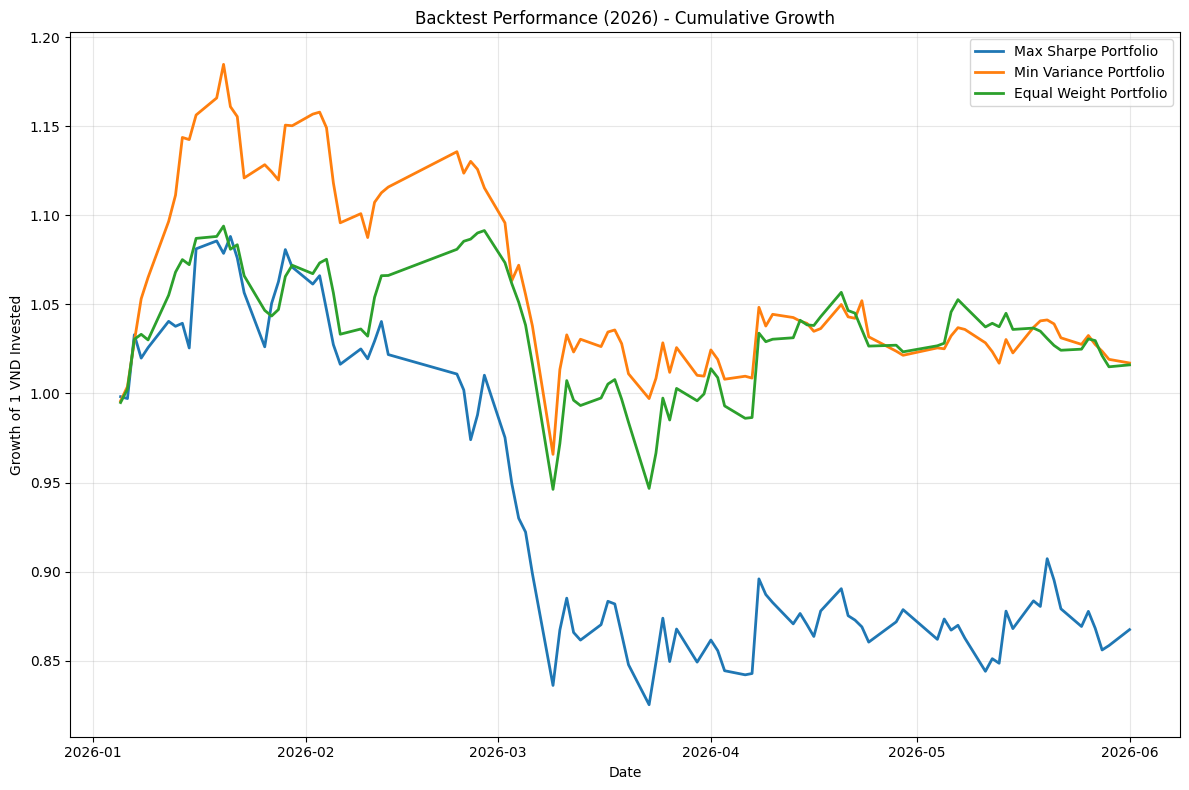

In [19]:
max_sharpe_return = (test_returns[stocks] * max_sharpe_weights_opt).sum(axis=1)
min_variance_return = (test_returns[stocks] * min_variance_weights_opt).sum(axis=1)
equal_weights = np.repeat(1 / n_assets, n_assets)
equal_return = (test_returns[stocks] * equal_weights).sum(axis=1)

backtest_result = pd.DataFrame({
    "Max Sharpe": max_sharpe_return,
    "Min Variance": min_variance_return,
    "Equal Weight": equal_return
})

performance = []
for col in backtest_result.columns:
    annual_return = ((1 + backtest_result[col]).prod()) ** (252 / len(backtest_result)) - 1
    annual_risk = backtest_result[col].std() * np.sqrt(252)
    sharpe = (annual_return - risk_free_rate) / annual_risk
    
    performance.append({
        "Portfolio": col,
        "Annual Return": annual_return,
        "Annual Risk": annual_risk,
        "Sharpe Ratio": sharpe
    })
performance = pd.DataFrame(performance)

print("\n=== Backtest Performance (2026) ===")
print(performance)

cumulative_return = (1 + backtest_result).cumprod()
plt.figure(figsize=(12,8))
for col in cumulative_return.columns:
    plt.plot(cumulative_return.index, cumulative_return[col], label=f"{col} Portfolio", linewidth=2)

plt.title("Backtest Performance (2026) - Cumulative Growth")
plt.xlabel("Date")
plt.ylabel("Growth of 1 VND Invested")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Phân tích kết quả Backtest danh mục đầu tư**

**Diễn biến tăng trưởng lũy kế của các danh mục**

Kết quả backtest được đánh giá thông qua giá trị tăng trưởng lũy kế của 1 VND vốn đầu tư ban đầu trong giai đoạn từ tháng 01/2026 đến tháng 06/2026. Ba danh mục được xem xét gồm danh mục tối đa hóa Sharpe Ratio (Max Sharpe Portfolio), danh mục tối thiểu hóa phương sai (Minimum Variance Portfolio) và danh mục phân bổ đều (Equal Weight Portfolio).

Trong giai đoạn đầu năm 2026, cả ba danh mục đều ghi nhận xu hướng tăng trưởng tích cực. Trong đó, danh mục Minimum Variance đạt mức tăng trưởng cao nhất, với giá trị tài sản tăng lên khoảng 1,18 lần so với vốn đầu tư ban đầu. Danh mục Equal Weight và Max Sharpe cũng tăng trưởng nhưng với tốc độ thấp hơn, duy trì quanh mức 1,05–1,08 lần vốn ban đầu.

Từ cuối tháng 02/2026 đến tháng 03/2026, thị trường xuất hiện nhịp điều chỉnh mạnh, kéo theo sự suy giảm của cả ba danh mục. Tuy nhiên, mức độ ảnh hưởng giữa các danh mục có sự khác biệt đáng kể. Danh mục Max Sharpe ghi nhận mức sụt giảm lớn nhất khi giá trị danh mục giảm xuống dưới 0,83 lần vốn ban đầu. Ngược lại, danh mục Minimum Variance duy trì mức giảm thấp hơn đáng kể và hình thành vùng đáy quanh mức 0,96 lần vốn đầu tư. Kết quả này phản ánh khả năng kiểm soát rủi ro tốt hơn của chiến lược tối thiểu hóa phương sai trong điều kiện thị trường biến động bất lợi.

Trong giai đoạn từ tháng 04/2026 đến tháng 06/2026, thị trường có xu hướng ổn định và phục hồi nhẹ. Danh mục Minimum Variance và Equal Weight dần lấy lại mức tăng trưởng dương, với giá trị tài sản vượt ngưỡng 1,0 lần vốn đầu tư ban đầu vào cuối kỳ. Trong khi đó, danh mục Max Sharpe có sự phục hồi nhưng vẫn duy trì dưới mức hòa vốn, cho thấy tác động kéo dài của giai đoạn suy giảm trước đó.

**Đánh giá hiệu quả các chiến lược phân bổ danh mục**

Kết quả backtest ngoài mẫu cho thấy sự khác biệt đáng kể giữa hiệu quả tối ưu hóa trong giai đoạn huấn luyện và hiệu quả thực tế trong giai đoạn kiểm định.

Đối với danh mục Max Sharpe, mặc dù đạt Sharpe Ratio cao nhất trong giai đoạn xây dựng mô hình, hiệu quả trong giai đoạn backtest lại không như kỳ vọng. Nguyên nhân chủ yếu đến từ việc danh mục có mức độ tập trung vốn cao vào một số cổ phiếu có hiệu suất vượt trội trong quá khứ. Khi điều kiện thị trường thay đổi, danh mục trở nên nhạy cảm hơn với biến động giá của các cổ phiếu này, dẫn đến mức suy giảm lớn và hiệu quả đầu tư thấp hơn.

Ngược lại, danh mục Minimum Variance thể hiện khả năng kiểm soát rủi ro tốt trong toàn bộ giai đoạn nghiên cứu. Việc phân bổ tỷ trọng dựa trên cấu trúc hiệp phương sai giúp danh mục hạn chế biến động và giảm thiểu tác động của các cú sốc thị trường. Nhờ đó, danh mục duy trì được mức sụt giảm thấp hơn trong giai đoạn điều chỉnh và đạt kết quả tích lũy cao nhất vào cuối kỳ.

Danh mục Equal Weight cho kết quả tương đối ổn định và có hiệu suất gần tương đương với danh mục Minimum Variance ở cuối giai đoạn nghiên cứu. Điều này cho thấy chiến lược phân bổ đều, mặc dù đơn giản và không sử dụng các kỹ thuật tối ưu hóa phức tạp, vẫn có khả năng tận dụng lợi ích của đa dạng hóa để giảm thiểu rủi ro danh mục.

>Nhìn chung, kết quả backtest cho thấy hiệu quả của một danh mục đầu tư không chỉ phụ thuộc vào khả năng tối đa hóa lợi nhuận kỳ vọng mà còn phụ thuộc đáng kể vào mức độ kiểm soát rủi ro và khả năng đa dạng hóa. Trong bối cảnh thị trường biến động, danh mục Minimum Variance cho thấy hiệu quả vượt trội nhờ duy trì được sự cân bằng giữa lợi nhuận và rủi ro, qua đó mang lại kết quả đầu tư ổn định hơn so với các chiến lược còn lại.
